In [1]:
import tensorflow as tf
from tensorflow import keras

/home/mahendra/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/home/mahendra/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/home/mahendra/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/home/mahendra/.local/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.

In [2]:
tf.__version__

'1.14.0'

In [3]:
keras.__version__

'2.2.4-tf'

In [4]:
fashion_mnist=keras.datasets.fashion_mnist

In [5]:
(X_train_full,y_train_full),(X_test,y_test)=fashion_mnist.load_data()

In [6]:
X_train_full.shape

(60000, 28, 28)

In [7]:
X_train_full.dtype

dtype('uint8')

In [8]:
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0

In [9]:
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

In [10]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [11]:
class_names[y_train[0]]

'Coat'

In [12]:
#lets build the neural network here is classification mlp with two hidden layers

In [13]:
model=keras.models.Sequential()
#creates a sequential model
model.add(keras.layers.Flatten(input_shape=[28,28]))
#building first layer and adding it to the model
#its flatten layer whose role is to convert input image into 1D array
#since it is the first layer in the model,you should specify the input_shape
model.add(keras.layers.Dense(300, activation="relu"))
#adding dense hidden layer with 300 neurons with relu activation function
model.add(keras.layers.Dense(100, activation="relu"))
#adding dense hidden layer with 100 neurons with relu activation function
model.add(keras.layers.Dense(10, activation="softmax"))
#finally ,we add a dense output layer with10 neurons(one per class),using the softmax activation function

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [14]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 300)               235500    
_________________________________________________________________
dense_1 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [15]:
model.layers

In [16]:
hidden1=model.layers[1]

In [17]:
hidden1.name

'dense'

In [19]:
model.get_layer('dense') is hidden1

True

In [20]:
weights,biases=hidden1.get_weights()

In [21]:
weights

array([[ 0.0137247 , -0.05197243,  0.04163156, ..., -0.0084805 ,
        -0.02688372, -0.05089148],
       [-0.00532292, -0.01737675,  0.00772874, ..., -0.04677979,
        -0.03716855, -0.02574641],
       [ 0.00284506, -0.02963091, -0.01799738, ..., -0.02275157,
         0.05477509, -0.04003533],
       ...,
       [ 0.05130841,  0.05498986,  0.01780584, ...,  0.04060102,
        -0.03784199,  0.04768772],
       [ 0.00424597, -0.00817329,  0.0614621 , ..., -0.01262165,
         0.0319726 ,  0.04309793],
       [ 0.01918725, -0.03948918, -0.03547878, ...,  0.04150032,
         0.06781033, -0.0671306 ]], dtype=float32)

In [22]:
weights.shape

(784, 300)

In [23]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [24]:
biases.shape

(300,)

In [25]:
#compiling the model
model.compile(loss="sparse_categorical_crossentropy",optimizer="sgd",metrics=["accuracy"])

In [26]:
history=model.fit(X_train,y_train,epochs=30,validation_data=(X_valid,y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/30
55000/55000 [==============================] - 6s 100us/sample - loss: 0.7273 - acc: 0.7609 - val_loss: 0.5136 - val_acc: 0.8324
Epoch 2/30
55000/55000 [==============================] - 5s 94us/sample - loss: 0.4911 - acc: 0.8286 - val_loss: 0.4421 - val_acc: 0.8534
Epoch 3/30
55000/55000 [==============================] - 5s 92us/sample - loss: 0.4450 - acc: 0.8427 - val_loss: 0.4412 - val_acc: 0.8470
Epoch 4/30
55000/55000 [==============================] - 5s 93us/sample - loss: 0.4181 - acc: 0.8527 - val_loss: 0.4246 - val_acc: 0.8510
Epoch 5/30
55000/55000 [==============================] - 5s 93us/sample - loss: 0.3978 - acc: 0.8595 - val_loss: 0.3862 - val_acc: 0.8688
Epoch 6/30
55000/55000 [==============================] - 5s 91us/sample - loss: 0.3810 - acc: 0.8646 - val_loss: 0.3966 - val_acc: 0.8608
Epoch 7/30
55000/55000 [==============================] - 5s 93us/sample - loss: 0.3690 - acc: 0.8683 - val_loss: 0.

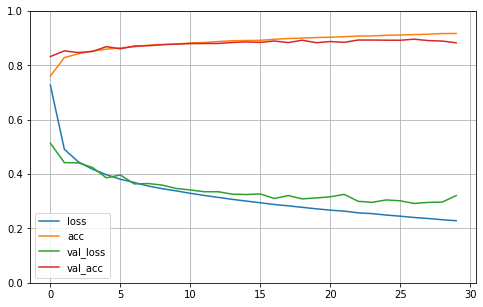

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [28]:
model.evaluate(X_test, y_test)

10000/10000 [==============================] - 0s 50us/sample - loss: 55.3286 - acc: 0.8566


[55.32861391830444, 0.8566]

In [29]:
X_new = X_test[:3]

In [30]:
y_proba = model.predict(X_new)

In [31]:
y_proba.round(2)

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [32]:
y_pred = model.predict_classes(X_new)

In [33]:
y_pred

array([9, 2, 1])

In [36]:
import numpy as np
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [37]:
y_new = y_test[:3]

In [38]:
y_new

array([9, 2, 1], dtype=uint8)